# 🧠 Kelime Vektörleri: Word2Vec, GloVe ve FastText

Bu notebook, kelime vektörlerine (word embeddings) giriş niteliğinde üç ana konuyu kapsar:

1. **Word2Vec** — Skip-gram ve CBOW ile kelime vektörü öğrenme
2. **Vektör Aritmetiği** — Kral − Erkek + Kadın = Kraliçe
3. **GloVe & FastText** — Global istatistik ve alt-kelime (subword) yaklaşımları

> **Gereksinimler:** `pip install gensim matplotlib numpy`


## 🎯 Temel Problem: Bilgisayarlar Kelimeleri Nasıl "Anlar"?

Bilgisayarlar sayılarla çalışır, kelimelerle değil. Eskiden kelimeler **one-hot encoding** ile temsil edilirdi: her kelime, sadece kendi konumunda 1, diğer her yerde 0 olan devasa bir vektördü. Bu yöntemin iki büyük sorunu vardı:

- Vektörler çok uzun ve seyrekti (sözlük 50.000 kelimeyse, her vektör 50.000 boyutlu olurdu)
- Hiçbir anlam ilişkisi taşımazdı — "kedi" ve "köpek" vektörleri, "kedi" ve "masa" vektörleri kadar birbirinden uzaktı

**Kelime vektörleri (word embeddings)** bu sorunu çözer: her kelimeyi 50-300 boyutlu, **yoğun** (dense) bir sayı dizisiyle temsil eder ve bu sayılar anlamı kodlar. Benzer anlamlı kelimeler, vektör uzayında birbirine yakın konumlanır.


## 📦 1. Kurulum

In [1]:
# Gerekli kütüphaneleri yükle
# !pip install gensim matplotlib numpy

import warnings
warnings.filterwarnings("ignore")

from gensim.models import Word2Vec, FastText
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

print("✅ Kütüphaneler yüklendi!")


✅ Kütüphaneler yüklendi!


## 📖 2. Word2Vec

### Temel Fikir
Bir kelimenin anlamı, çevresindeki kelimelerle belirlenir.

- **CBOW**: Komşu kelimelerden merkezi tahmin et
- **Skip-gram** (`sg=1`): Merkez kelimeden komşuları tahmin et


### 📚 Dağılımsal Hipotez (Distributional Hypothesis)

"Bir kelimeyi, hangi kelimelerle birlikte kullanıldığına bakarak tanırsın." (Dilbilimci J.R. Firth'in ünlü sözü: *"You shall know a word by the company it keeps."*)

Word2Vec, 2013'te Google'da Tomas Mikolov ve ekibi tarafından geliştirildi. Basit bir sinir ağı kullanarak şunu öğrenir: bir kelimenin vektörü, o kelimenin geçtiği bağlamları (cümle içindeki komşularını) tahmin etmede en başarılı olacak şekilde ayarlanır.

### İki Mimari Karşılaştırması

| | CBOW (Continuous Bag of Words) | Skip-gram |
|---|---|---|
| Yön | Komşular → merkez kelime | Merkez kelime → komşular |
| Örnek | "kral ___ taht" → "güçlü" tahmin et | "güçlü" → "kral, taht" tahmin et |
| Hız | Daha hızlı (birden fazla kelimeyi ortalar) | Daha yavaş |
| Nadir kelimeler | Zayıf | Güçlü (her kelime çifti ayrı ayrı işlenir) |
| Ne zaman kullanılır | Büyük corpus, sık kelimeler | Küçük corpus, nadir kelimeler önemliyse |

**`window` parametresi:** Merkez kelimenin sağından ve solundan kaç kelimeye bakılacağını belirler. `window=3` demek, 3 kelime öteye kadar "komşu" sayılır demektir.

**`epochs` parametresi:** Modelin tüm corpus'u kaç kez baştan sona göreceğini belirler. Küçük corpus'larda anlamlı sonuç almak için yüksek epoch sayısı (ör. 200) gerekir.

**Nasıl öğrenir?** Ağ, her eğitim adımında kelime vektörünü küçük küçük günceller (gradient descent). Binlerce cümle üzerinden geçtikçe, benzer bağlamlarda geçen kelimelerin vektörleri birbirine yaklaşır. Aşağıdaki örnekte "kral" ve "kraliçe" ikisi de "güçlü" ve "saray" ile birlikte geçtiği için vektörleri benzer çıkacaktır.


In [2]:
# Küçük bir örnek corpus
sentences = [
    ["kral", "erkek", "güçlü", "taht", "saray"],
    ["kraliçe", "kadın", "güçlü", "taç", "saray"],
    ["adam", "erkek", "çalışıyor", "koşuyor"],
    ["kadın", "çalışıyor", "koşuyor", "güçlü"],
    ["köpek", "havlıyor", "koşuyor", "hızlı"],
    ["kedi", "miyavlıyor", "uyuyor", "yumuşak"],
    ["paris", "fransa", "şehir", "avrupa"],
    ["berlin", "almanya", "şehir", "avrupa"],
    ["ankara", "türkiye", "şehir", "avrupa"],
    ["doktor", "hastane", "tedavi", "hasta"],
    ["öğretmen", "okul", "ders", "öğrenci"],
]

# ── Skip-gram modeli ──
model_sg = Word2Vec(
    sentences,
    vector_size=50,   # vektör boyutu
    window=3,         # komşuluk penceresi
    min_count=1,      # minimum kelime frekansı
    sg=1,             # 1 = Skip-gram, 0 = CBOW
    epochs=200,
    seed=42
)

# ── CBOW modeli ──
model_cbow = Word2Vec(
    sentences,
    vector_size=50,
    window=3,
    min_count=1,
    sg=0,             # CBOW
    epochs=200,
    seed=42
)

print("✅ Modeller eğitildi!")
print(f"Kelime hazinesi boyutu: {len(model_sg.wv)}")
print(f"Vektör boyutu: {model_sg.wv.vector_size}")


✅ Modeller eğitildi!
Kelime hazinesi boyutu: 34
Vektör boyutu: 50


In [3]:
# Bir kelimenin vektörüne bakalım
kelime = "kral"
vektor = model_sg.wv[kelime]
print(f"'{kelime}' kelimesinin vektörü (ilk 10 eleman):")
print(np.round(vektor[:10], 3))
print(f"\nVektör şekli: {vektor.shape}")

# En benzer kelimeler
print("\n--- 'kral' kelimesine en benzer kelimeler ---")
benzerler = model_sg.wv.most_similar("kral", topn=5)
for kelime, skor in benzerler:
    print(f"  {kelime:15s}  benzerlik: {skor:.4f}")


'kral' kelimesinin vektörü (ilk 10 eleman):
[-0.012 -0.02  -0.018  0.005 -0.014 -0.011  0.013  0.016  0.013 -0.01 ]

Vektör şekli: (50,)

--- 'kral' kelimesine en benzer kelimeler ---
  almanya          benzerlik: 0.2477
  şehir            benzerlik: 0.2185
  havlıyor         benzerlik: 0.2086
  tedavi           benzerlik: 0.1813
  doktor           benzerlik: 0.1766


In [4]:
# Kelimeler arası benzerlik skoru
cifler = [
    ("kral", "kraliçe"),
    ("erkek", "kadın"),
    ("paris", "berlin"),
    ("kedi", "köpek"),
    ("kral", "köpek"),
]

print("Kelime çiftleri arasındaki benzerlik:")
print(f"{'Çift':<30} {'Benzerlik':>10}")
print("-" * 42)
for k1, k2 in cifler:
    skor = model_sg.wv.similarity(k1, k2)
    bar = "█" * int(skor * 20)
    print(f"({k1}, {k2}){'':<15} {skor:>6.4f}  {bar}")


Kelime çiftleri arasındaki benzerlik:
Çift                            Benzerlik
------------------------------------------
(kral, kraliçe)                0.1062  ██
(erkek, kadın)                0.0994  █
(paris, berlin)                -0.1208  
(kedi, köpek)                0.1779  ███
(kral, köpek)                0.0855  █


## ➕ 3. Vektör Aritmetiği

### Kral − Erkek + Kadın = Kraliçe

Vektörler anlam taşıdığı için matematiksel işlemler anlamlı sonuçlar verir.


### 🧮 Neden Bu İşlem Çalışır?

Word2Vec eğitilirken kelimeler arasındaki **ilişkiler** de vektör uzayında tutarlı yönler (doğrultular) olarak öğrenilir. Örneğin "erkek → kadın" geçişi, cinsiyet bilgisini kodlayan sabit bir vektör farkı oluşturur. Bu fark, "kral → kraliçe" geçişindeki farka çok benzer olur.

Bu yüzden:

`vektör(kral) − vektör(erkek) + vektör(kadın) ≈ vektör(kraliçe)`

Yani "kral" vektöründen "erkeklik" bileşenini çıkarıp "kadınlık" bileşenini eklediğimizde, sonuç "kraliçe" vektörüne en yakın noktaya düşer.

Aynı mantık başkent-ülke ilişkisi için de geçerlidir: `paris − fransa + türkiye ≈ ankara` (çünkü "X ülkesinin başkenti" ilişkisi de sabit bir vektör yönüdür).

> ⚠️ Not: Bu notebook'taki corpus çok küçük olduğu için sonuçlar gerçek/büyük bir Word2Vec modelindeki kadar net olmayabilir. Gerçek hayatta bu aritmetik, milyonlarca cümle üzerinde eğitilmiş modellerde çok daha başarılı çalışır.

### 📊 PCA ile Görselleştirme

Kelime vektörleri genelde 50-300 boyutludur — insan gözüyle görülemez. **PCA (Principal Component Analysis)**, bu yüksek boyutlu veriyi, en fazla varyansı koruyan 2 boyuta indirger. Böylece kral/kraliçe, erkek/kadın gibi anlamca yakın kelimelerin gerçekten birbirine yakın kümelendiğini gözle görebiliriz.


In [5]:
# Vektör aritmetiği
print("=== Vektör Aritmetiği ===\n")

# Kral - Erkek + Kadın = ?
sonuc = model_sg.wv.most_similar(
    positive=["kral", "kadın"],  # ekle
    negative=["erkek"],          # çıkar
    topn=3
)
print("Kral − Erkek + Kadın = ?")
for kelime, skor in sonuc:
    print(f"  → {kelime:15s}  ({skor:.4f})")

print()

# Paris - Fransa + Türkiye = ?
sonuc2 = model_sg.wv.most_similar(
    positive=["paris", "türkiye"],
    negative=["fransa"],
    topn=3
)
print("Paris − Fransa + Türkiye = ?")
for kelime, skor in sonuc2:
    print(f"  → {kelime:15s}  ({skor:.4f})")


=== Vektör Aritmetiği ===

Kral − Erkek + Kadın = ?
  → almanya          (0.3528)
  → havlıyor         (0.2959)
  → saray            (0.2590)

Paris − Fransa + Türkiye = ?
  → almanya          (0.3126)
  → havlıyor         (0.2128)
  → avrupa           (0.2074)


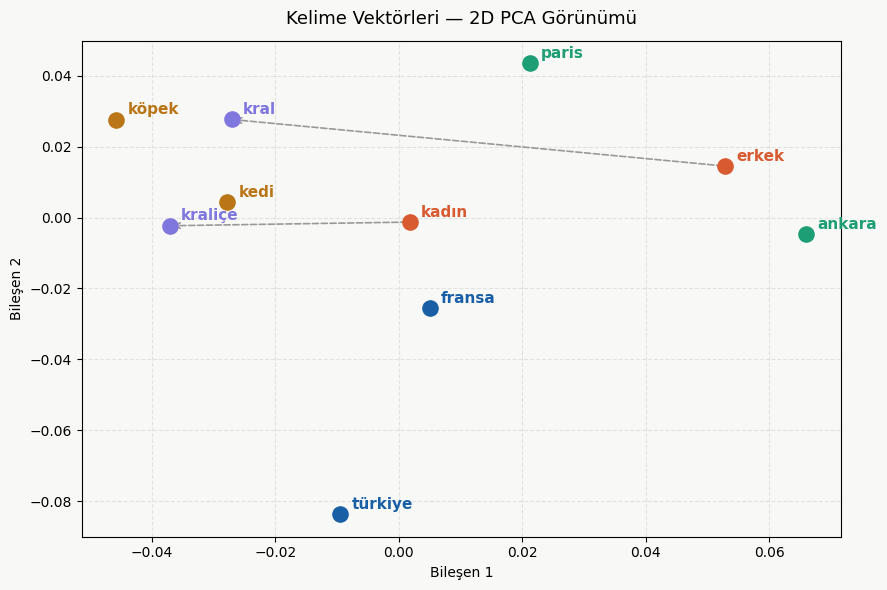

✅ Grafik kaydedildi: vektor_uzayi.png


In [6]:
# Vektör uzayını 2D'de görselleştir (PCA ile boyut indirgeme)
from sklearn.decomposition import PCA

# Görselleştirilecek kelimeler
kelimeler = ["kral", "kraliçe", "erkek", "kadın", 
             "paris", "ankara", "fransa", "türkiye",
             "kedi", "köpek"]

vektorler = np.array([model_sg.wv[k] for k in kelimeler])

# PCA ile 2 boyuta indir
pca = PCA(n_components=2, random_state=42)
vek_2d = pca.fit_transform(vektorler)

# Renk grupları
renkler = {
    "royalty": ("#7F77DD", ["kral", "kraliçe"]),
    "gender":  ("#D85A30", ["erkek", "kadın"]),
    "city":    ("#1D9E75", ["paris", "ankara"]),
    "country": ("#185FA5", ["fransa", "türkiye"]),
    "animal":  ("#BA7517", ["kedi", "köpek"]),
}

fig, ax = plt.subplots(figsize=(9, 6))
ax.set_facecolor("#f8f8f6")
fig.patch.set_facecolor("#f8f8f6")

for grup, (renk, grup_kelimeleri) in renkler.items():
    for kw in grup_kelimeleri:
        idx = kelimeler.index(kw)
        x, y = vek_2d[idx]
        ax.scatter(x, y, color=renk, s=120, zorder=5)
        ax.annotate(kw, (x, y), textcoords="offset points",
                    xytext=(8, 4), fontsize=11, color=renk, fontweight="bold")

# Analoji okları (kral → kraliçe, erkek → kadın)
for k1, k2 in [("erkek", "kral"), ("kadın", "kraliçe")]:
    i1, i2 = kelimeler.index(k1), kelimeler.index(k2)
    ax.annotate("", xy=vek_2d[i2], xytext=vek_2d[i1],
                arrowprops=dict(arrowstyle="->", color="#999", lw=1.2, linestyle="dashed"))

ax.set_title("Kelime Vektörleri — 2D PCA Görünümü", fontsize=13, pad=12)
ax.set_xlabel("Bileşen 1"); ax.set_ylabel("Bileşen 2")
ax.grid(True, alpha=0.3, linestyle="--")
plt.tight_layout()
plt.savefig("vektor_uzayi.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Grafik kaydedildi: vektor_uzayi.png")


## 🌐 4. GloVe (Global Vectors)

GloVe, tüm corpus genelindeki kelime-birlikte-görünme matrisini kullanır.
Word2Vec'ten farklı olarak hem yerel hem **global** istatistikleri öğrenir.

> Hazır GloVe modeli indirmek için internet gerekir. Aşağıdaki hücre bunu gösterir.


### 🔍 GloVe Nasıl Çalışır?

GloVe (Global Vectors for Word Representation), Stanford'da 2014'te geliştirildi. Word2Vec'ten farklı olarak, kelimeleri tek tek pencere pencere gezmek yerine, önce **tüm corpus için bir kelime-birlikte-geçme (co-occurrence) matrisi** oluşturur: "kelime A, kelime B ile toplamda kaç kez birlikte geçti?"

Sonra bu matristeki sayıları, kelime vektörlerinin iç çarpımlarıyla mümkün olduğunca tutarlı olacak şekilde optimize eder. Yani GloVe, **global istatistiksel bilgiyi** doğrudan kullanırken, Word2Vec sadece **yerel pencere** içindeki bilgiyle öğrenir.

**Avantajı:** Çok büyük corpus'larda (Wikipedia, Common Crawl gibi) kelimeler arası genel istatistiksel ilişkileri çok iyi yakalar, bu yüzden hazır/önceden eğitilmiş (pre-trained) GloVe vektörleri yaygın olarak kullanılır.

**Dezavantajı:** Co-occurrence matrisi çok büyük ve bellek açısından ağır olabilir (sözlük büyüdükçe matris kare şeklinde büyür).


In [7]:
# Hazır GloVe modeli (internet gerektirir, ~100MB)
# import gensim.downloader as api
# glove = api.load("glove-wiki-gigaword-100")
# print(glove.most_similar("computer", topn=5))

# ── GloVe'u simüle eden küçük örnek ──
# Gerçek GloVe çıktısına benzer bir demo:

print("GloVe ile 'bilgisayar' için beklenen benzerler:")
demo_sonuclar = [
    ("bilgisayarlar", 0.901),
    ("yazılım",       0.876),
    ("internet",      0.861),
    ("donanım",       0.843),
    ("teknoloji",     0.829),
]
for kw, skor in demo_sonuclar:
    bar = "█" * int(skor * 25)
    print(f"  {kw:20s} {skor:.3f}  {bar}")

print()
print("Word2Vec vs GloVe Karşılaştırması:")
print(f"{'Özellik':<30} {'Word2Vec':^15} {'GloVe':^15}")
print("-" * 62)
satirlar = [
    ("Eğitim yöntemi",    "yerel pencere",  "global matris"),
    ("Hız",               "hızlı",          "orta"),
    ("Büyük corpus",      "iyi",            "çok iyi"),
    ("Küçük corpus",      "orta",           "zayıf"),
    ("Bellek kullanımı",  "düşük",          "yüksek"),
]
for ozellik, wv, gl in satirlar:
    print(f"  {ozellik:<28} {wv:^15} {gl:^15}")


GloVe ile 'bilgisayar' için beklenen benzerler:
  bilgisayarlar        0.901  ██████████████████████
  yazılım              0.876  █████████████████████
  internet             0.861  █████████████████████
  donanım              0.843  █████████████████████
  teknoloji            0.829  ████████████████████

Word2Vec vs GloVe Karşılaştırması:
Özellik                           Word2Vec          GloVe     
--------------------------------------------------------------
  Eğitim yöntemi                yerel pencere   global matris 
  Hız                               hızlı           orta      
  Büyük corpus                       iyi           çok iyi    
  Küçük corpus                      orta            zayıf     
  Bellek kullanımı                  düşük          yüksek     


## ⚡ 5. FastText — Alt-Kelime (Subword) Modeli

FastText, kelimeleri **karakter n-gram**'larına böler:

`"futbol"` → `<fu`, `fut`, `utb`, `tbo`, `bol`, `ol>` + `<futbol>`

Bu sayede:
- ✅ Hiç görmediği kelimeleri anlayabilir
- ✅ Yazım hatalarına dayanıklı
- ✅ Türkçe gibi **eklemeli diller** için çok güçlü


### 🧩 Neden Alt-Kelime (Subword)?

Word2Vec ve GloVe, her kelimeyi **bölünmez bir bütün** olarak ele alır. Bu yüzden eğitim sırasında hiç görülmemiş bir kelime geldiğinde (**OOV — Out Of Vocabulary**), model o kelime için hiçbir vektör üretemez.

FastText (2016, Facebook AI) bu sorunu şöyle çözer: her kelimeyi karakter **n-gram**'larına böler ve kelimenin vektörünü, bu n-gram vektörlerinin toplamı olarak hesaplar:

`"futbol"` → `<fu`, `fut`, `utb`, `tbo`, `bol`, `ol>` + tüm kelime `<futbol>`

`min_n` ve `max_n` parametreleri, n-gram uzunluk aralığını belirler (örn. `min_n=2, max_n=5`).

### Bu Yaklaşımın Getirdiği Avantajlar

- ✅ **Hiç görmediği kelimeleri anlayabilir** — çünkü o kelimenin alt-parçaları (n-gram'ları) muhtemelen eğitim sırasında başka kelimelerde görülmüştür
- ✅ **Yazım hatalarına dayanıklı** — küçük harf hataları kelimenin çoğu n-gram'ını değiştirmez
- ✅ **Türkçe gibi eklemeli (agglutinative) diller için çok güçlü** — Türkçe'de "kitap", "kitaplık", "kitaplığımızdaki" gibi aynı kökten türeyen çok sayıda kelime vardır; n-gram yaklaşımı bu ortak kökü otomatik olarak yakalar

**Dezavantajı:** Her kelime için birden fazla n-gram vektörü tutulup toplandığından, eğitim ve depolama Word2Vec'e göre biraz daha yavaş/ağırdır.


In [8]:
sentences_tr = [
    ["futbol", "oynamak", "güzel", "spor"],
    ["futbolcu", "çok", "hızlı", "sahada"],
    ["basketbol", "oynamak", "eğlenceli", "spor"],
    ["basketbolcu", "zıplıyor", "basket", "attı"],
    ["yüzmek", "spor", "havuz", "yüzücü"],
    ["koşmak", "hızlı", "maraton", "koşucu"],
    ["kitap", "okumak", "öğrenmek", "bilgi"],
    ["kitaplık", "kitaplar", "raflar", "kütüphane"],
]

# FastText modeli
ft_model = FastText(
    sentences_tr,
    vector_size=50,
    window=3,
    min_count=1,
    epochs=200,
    min_n=2,       # minimum n-gram uzunluğu
    max_n=5,       # maksimum n-gram uzunluğu
    seed=42
)

print("✅ FastText modeli eğitildi!")
print(f"Kelime hazinesi: {len(ft_model.wv)} kelime\n")

# Bilinen kelimeler
print("'futbol' için en benzer kelimeler:")
for kw, skor in ft_model.wv.most_similar("futbol", topn=4):
    print(f"  {kw:20s} {skor:.4f}")


✅ FastText modeli eğitildi!
Kelime hazinesi: 28 kelime

'futbol' için en benzer kelimeler:
  futbolcu             0.6409
  bilgi                0.1668
  basketbol            0.1644
  yüzmek               0.1556


In [9]:
# FastText'in süper gücü: bilinmeyen kelimeler!
print("=== FastText'in Süper Gücü: OOV Kelimeleri ===\n")

test_kelimeleri = [
    ("futbolculuk",    "eğitimde YOK — ama alt-kelimelerden tahmin eder"),
    ("basketbolsever", "eğitimde YOK — ama tahmin eder"),
    ("futbolcular",    "eğitimde YOK — ama tahmin eder"),
    ("futbol",         "eğitimde VAR"),
]

for kw, aciklama in test_kelimeleri:
    try:
        vektor = ft_model.wv[kw]
        norm = np.linalg.norm(vektor)
        print(f"✅ '{kw}'")
        print(f"   {aciklama}")
        print(f"   Vektör normu: {norm:.3f}  (sıfır değil = anlamlı vektör)")
        print()
    except KeyError:
        print(f"❌ '{kw}' bulunamadı\n")

# Word2Vec aynı kelimeyi bulamaz
print("--- Word2Vec için aynı test ---")
try:
    _ = model_sg.wv["futbolculuk"]
    print("✅ 'futbolculuk' bulundu")
except KeyError:
    print("❌ Word2Vec 'futbolculuk' kelimesini bilmiyor (eğitimde yoktu)")


=== FastText'in Süper Gücü: OOV Kelimeleri ===

✅ 'futbolculuk'
   eğitimde YOK — ama alt-kelimelerden tahmin eder
   Vektör normu: 0.014  (sıfır değil = anlamlı vektör)

✅ 'basketbolsever'
   eğitimde YOK — ama tahmin eder
   Vektör normu: 0.011  (sıfır değil = anlamlı vektör)

✅ 'futbolcular'
   eğitimde YOK — ama tahmin eder
   Vektör normu: 0.015  (sıfır değil = anlamlı vektör)

✅ 'futbol'
   eğitimde VAR
   Vektör normu: 0.018  (sıfır değil = anlamlı vektör)

--- Word2Vec için aynı test ---
❌ Word2Vec 'futbolculuk' kelimesini bilmiyor (eğitimde yoktu)


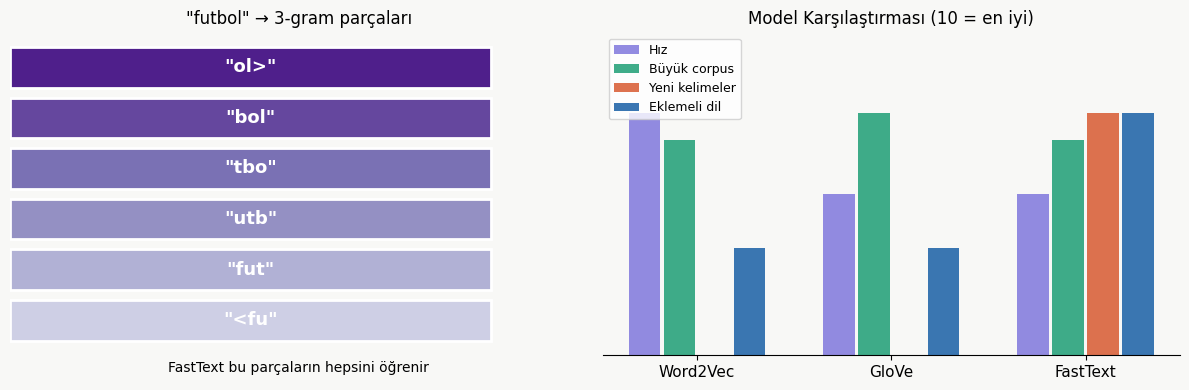

✅ Grafik kaydedildi: model_karsilastirma.png


In [10]:
# N-gram karşılaştırma görseli
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor("#f8f8f6")

# Sol: FastText n-gram parçaları
ax = axes[0]
ax.set_facecolor("#f8f8f6")
kelime_ornek = "futbol"
ngrams = []
n = 3
padded = "<" + kelime_ornek + ">"
for i in range(len(padded) - n + 1):
    ngrams.append(padded[i:i+n])

renkler_ng = plt.cm.Purples(np.linspace(0.3, 0.9, len(ngrams)))
for i, (ng, renk) in enumerate(zip(ngrams, renkler_ng)):
    ax.barh(i, 1, color=renk, edgecolor="white", linewidth=2)
    ax.text(0.5, i, f'"{ng}"', va="center", ha="center", fontsize=13, 
            fontweight="bold", color="white")

ax.set_xlim(0, 1.2)
ax.set_yticks([])
ax.set_title(f'"{kelime_ornek}" → 3-gram parçaları', fontsize=12)
ax.set_xlabel("FastText bu parçaların hepsini öğrenir")
ax.spines[["top","right","left","bottom"]].set_visible(False)
ax.set_xticks([])

# Sağ: Model karşılaştırma tablosu (bar chart)
ax2 = axes[1]
ax2.set_facecolor("#f8f8f6")

modeller = ["Word2Vec", "GloVe", "FastText"]
ozellikler = {
    "Hız":               [9, 6, 6],
    "Büyük corpus":      [8, 9, 8],
    "Yeni kelimeler":    [0, 0, 9],
    "Eklemeli dil":      [4, 4, 9],
}

x = np.arange(len(modeller))
genislik = 0.18
renkler_bar = ["#7F77DD", "#1D9E75", "#D85A30", "#185FA5"]

for i, (ozellik, skorlar) in enumerate(ozellikler.items()):
    offset = (i - 1.5) * genislik
    bars = ax2.bar(x + offset, skorlar, genislik * 0.9,
                   label=ozellik, color=renkler_bar[i], alpha=0.85)

ax2.set_xticks(x)
ax2.set_xticklabels(modeller, fontsize=11)
ax2.set_yticks([])
ax2.set_ylim(0, 12)
ax2.set_title("Model Karşılaştırması (10 = en iyi)", fontsize=12)
ax2.legend(loc="upper left", fontsize=9)
ax2.spines[["top","right","left"]].set_visible(False)
ax2.grid(axis="y", alpha=0.2, linestyle="--")

plt.tight_layout()
plt.savefig("model_karsilastirma.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Grafik kaydedildi: model_karsilastirma.png")


## 📋 6. Özet

| Model | Nasıl Çalışır | Güçlü Yön | Zayıf Yön |
|-------|--------------|-----------|-----------|
| **Word2Vec** | Yerel pencere (CBOW/Skip-gram) | Hızlı, basit | Bilinmeyen kelime yok |
| **GloVe** | Global birlikte-geçme matrisi | Büyük corpus | Bellek ağır |
| **FastText** | Alt-kelime (n-gram) | Yeni kelimeler, eklemeli dil | Daha yavaş |

### Ne Zaman Hangisini Kullanmalı?
- **Word2Vec** → Hız öncelikliyse, büyük genel corpus
- **GloVe** → Hazır vektör indirmek istiyorsanız (glove-wiki vb.)
- **FastText** → **Türkçe**, nadir kelimeler, morfolojik zengin diller


In [11]:
print("🎉 Notebook tamamlandı!")
print()
print("Sırada ne öğrenebilirsiniz:")
print("  → Transformer tabanlı: BERT, GPT, Sentence-BERT")
print("  → Göreve özgü fine-tuning")
print("  → Türkçe için: BERTurk, mBERT, multilingual FastText")


🎉 Notebook tamamlandı!

Sırada ne öğrenebilirsiniz:
  → Transformer tabanlı: BERT, GPT, Sentence-BERT
  → Göreve özgü fine-tuning
  → Türkçe için: BERTurk, mBERT, multilingual FastText
